In [2]:
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "/Users/jimartin/Work/TESS/tess-asteroid-ml/data/jpl"

In [11]:
example = pd.read_csv(f"{PATH}/jpl_small_bodies_tess_s0001-1-0_catalog.csv", index_col=0)
example.columns

/var/folders/9v/pf39l8vn4dv810cyn39k_xk05nh7q7/T/ipykernel_45838/2383747143.py:1: DtypeWarning: Columns (4,12) have mixed types. Specify dtype option on import or set low_memory=False.
  example = pd.read_csv(f"{PATH}/jpl_small_bodies_tess_s0001-1-0_catalog.csv", index_col=0)


Index(['Object name', 'Astrometric RA (hh:mm:ss)',
       'Astrometric Dec (dd mm'ss")', 'Visual magnitude (V)', 'RA rate ("/h)',
       'Dec rate ("/h)', 'ra', 'dec', 'V_mag', 'name', 'id',
       'Absolute magntiude (H)', 'Magnitude slope (G)', 'Eccentricity',
       'Perihelion (au)', 'Time of perihelion passage (JD)',
       'Longitude of ascending node (deg)', 'Argument of perihelion (deg)',
       'Inclination (deg)', 'Epoch (JD)', 'H_mag', 'kind'],
      dtype='object')

In [23]:
example.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40739 entries, 0 to 40738
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Object name                        40739 non-null  object 
 1   Astrometric RA (hh:mm:ss)          40670 non-null  object 
 2   Astrometric Dec (dd mm'ss")        40670 non-null  object 
 3   Visual magnitude (V)               40670 non-null  object 
 4   RA rate ("/h)                      40670 non-null  float64
 5   Dec rate ("/h)                     40670 non-null  float64
 6   ra                                 40670 non-null  float64
 7   dec                                40670 non-null  float64
 8   V_mag                              40670 non-null  float64
 9   name                               20836 non-null  object 
 10  id                                 40739 non-null  object 
 11  Absolute magntiude (H)             40739 non-null  obj

In [71]:
sec = 36

for cam in range(1, 5):
    print(sec, cam)
    files = sorted(glob(f"{PATH}/jpl_small_bodies_tess_s{sec:04}-{cam}-*_catalog.csv"))
    files_elem = sorted(glob(f"{PATH}/jpl_small_bodies_tess_s{sec:04}-{cam}-*_catalog_elem.csv"))
    
    print(len(files), len(files_elem))
    
    df = pd.concat([pd.read_csv(x, index_col=0) for x in files], axis=0
                  ).drop_duplicates(subset=["Object name"]).reset_index(drop=True)
    df_elem = pd.concat([pd.read_csv(x, index_col=0) for x in files_elem], axis=0
                       ).drop_duplicates(subset=["Object name"]).reset_index(drop=True)
    
    print(df.shape, df_elem.shape)
    
    df_merge = pd.merge(df, df_elem, how="outer", on=["Object name", "name", "id"])
    df_merge["kind"] = "a"
    df_merge.loc[np.isnan(df_merge.H_mag), "kind"] = "c"
    
    df_merge.to_csv(f"{PATH}/jpl_small_bodies_tess_s{sec:04}-{cam}-0_catalog.csv")
    
    df_merge.head()

36 1
4 4
(29862, 14) (29861, 13)
36 2
4 4
(1763, 14) (1763, 13)
36 3
4 4
(130, 14) (130, 13)
36 4
4 4
(56, 14) (56, 13)


In [44]:
track = pd.read_feather(glob(f"{PATH}/tracks/sector{sec:04}/tess-ffi_s0027-0-0_*_hires.feather")[0])
track

,time,sector,camera,ccd,column,row,pixels_per_hour,ra,dec,vmag,sun_distance,obs_distance,phase_angle
0,2.459041e+06,27,1,3,44.707277,886.599652,1.235512,313.088652,-28.730178,16.219136,2.455244,1.484854,8.872425
1,2.459041e+06,27,1,3,44.927528,886.652991,1.235616,313.087487,-28.730810,16.218966,2.455234,1.484819,8.869911
2,2.459041e+06,27,1,3,45.147791,886.706339,1.235721,313.086322,-28.731443,16.218796,2.455225,1.484785,8.867397
3,2.459041e+06,27,1,3,45.368068,886.759696,1.235826,313.085157,-28.732075,16.218627,2.455216,1.484750,8.864883
4,2.459041e+06,27,1,3,45.588357,886.813061,1.235931,313.083992,-28.732707,16.218457,2.455207,1.484716,8.862370
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,2.459061e+06,27,1,3,772.994102,989.316054,1.598809,308.890527,-30.433401,15.933023,2.429971,1.428235,4.958088
2696,2.459061e+06,27,1,3,773.265479,989.352091,1.600057,308.888894,-30.434017,15.933134,2.429962,1.428225,4.959280
2697,2.459061e+06,27,1,3,773.536989,989.388173,1.601314,308.887261,-30.434633,15.933247,2.429954,1.428216,4.960475
2698,2.459061e+06,27,1,3,773.808634,989.424301,1.602581,308.885627,-30.435250,15.933361,2.429945,1.428207,4.961672


In [49]:
track.time.values[-1] - track.time.values[0]

19.77054567448795

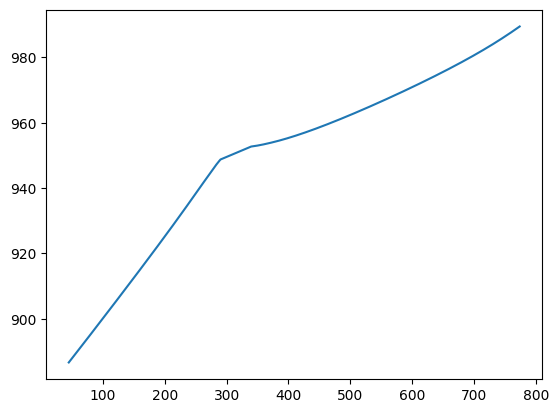

In [50]:
plt.plot(track.column, track.row)